# Exploratory Data Analysis (EDA): Student Engagement

This notebook performs EDA on two datasets:
- `Dataset/image_data.csv`
- `Dataset/text_data.csv`

Analysis goals:
1. Understand structure and data quality.
2. Explore engagement and behavior distributions.
3. Analyze numeric patterns (attention, session duration, engagement score).
4. Inspect keyword and text-related patterns.
5. Merge both sources on `sample_id` for cross-modal insights.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

BASE_PATH = Path.cwd()
IMAGE_PATH = BASE_PATH / 'Dataset' / 'image_data.csv'
TEXT_PATH = BASE_PATH / 'Dataset' / 'text_data.csv'

print('Working directory:', BASE_PATH)
print('Image data path exists:', IMAGE_PATH.exists())
print('Text data path exists:', TEXT_PATH.exists())

Working directory: d:\Pendidikan\Aset_Kuliah_S2\2_Kuliah\Semester_2\APDM\Project_repo\Project_APDM_Analisis_Engagement_Student
Image data path exists: True
Text data path exists: True


In [2]:
image_df = pd.read_csv(IMAGE_PATH)
text_df = pd.read_csv(TEXT_PATH)

print('image_df shape:', image_df.shape)
print('text_df shape:', text_df.shape)

display(image_df.head(3))
display(text_df.head(3))

image_df shape: (5000, 9)
text_df shape: (5000, 10)


,sample_id,image_name,engagement,behavior,age,gender,device,attention_score,session_duration
0,38615ca3-f04f-4a01-8793-a4bb362fbd69,0020.jpg,Engaged,Confused,23,Male,Laptop,0.30,100
1,667b0dd6-edcf-4b9e-8c9f-fbeff5165fc3,0021.jpg,Engaged,Confused,22,Female,Laptop,0.72,51
2,58434a4d-a70c-4757-a01f-3a866654ccc8,0032.jpg,Engaged,Confused,24,Female,Mobile,0.67,53


,sample_id,image_name,engagement,behavior,short_text,detailed_text,attention_score,engagement_score,keywords,text_length
0,38615ca3-f04f-4a01-8793-a4bb362fbd69,0020.jpg,Engaged,Confused,Learner shows confusion,Learner shows confusion during learning session,0.42,0.94,"focus, attention",3
1,667b0dd6-edcf-4b9e-8c9f-fbeff5165fc3,0021.jpg,Engaged,Confused,Learner shows confusion,Learner shows confusion during learning session,0.52,0.52,"learning, fatigue",3
2,58434a4d-a70c-4757-a01f-3a866654ccc8,0032.jpg,Engaged,Confused,Student appears confused,Student appears confused during learning session,0.76,0.36,"attention, fatigue",3


In [3]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sample_id         5000 non-null   object 
 1   image_name        5000 non-null   object 
 2   engagement        5000 non-null   object 
 3   behavior          5000 non-null   object 
 4   short_text        5000 non-null   object 
 5   detailed_text     5000 non-null   object 
 6   attention_score   5000 non-null   float64
 7   engagement_score  5000 non-null   float64
 8   keywords          5000 non-null   object 
 9   text_length       5000 non-null   int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 390.8+ KB


In [4]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sample_id         5000 non-null   object 
 1   image_name        5000 non-null   object 
 2   engagement        5000 non-null   object 
 3   behavior          5000 non-null   object 
 4   age               5000 non-null   int64  
 5   gender            5000 non-null   object 
 6   device            5000 non-null   object 
 7   attention_score   5000 non-null   float64
 8   session_duration  5000 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 351.7+ KB


## 1) Data Structure and Quality Checks

In [5]:
def quality_report(df, name):
    print(f'\n===== {name} =====')
    print('Shape:', df.shape)
    print('\nDtypes:')
    display(df.dtypes.to_frame('dtype'))

    missing = df.isna().sum().rename('missing_count').to_frame()
    missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
    print('\nMissing values:')
    display(missing)

    duplicate_rows = df.duplicated().sum()
    duplicate_ids = df['sample_id'].duplicated().sum() if 'sample_id' in df.columns else np.nan
    print('Duplicate rows:', duplicate_rows)
    print('Duplicate sample_id:', duplicate_ids)

    print('\nNumeric summary:')
    display(df.describe(include=[np.number]).T)

quality_report(image_df, 'Image Dataset')
quality_report(text_df, 'Text Dataset')


===== Image Dataset =====
Shape: (5000, 9)

Dtypes:


,dtype
sample_id,object
image_name,object
engagement,object
behavior,object
age,int64
gender,object
device,object
attention_score,float64
session_duration,int64



Missing values:


,missing_count,missing_pct
sample_id,0,0.0
image_name,0,0.0
engagement,0,0.0
behavior,0,0.0
age,0,0.0
gender,0,0.0
device,0,0.0
attention_score,0,0.0
session_duration,0,0.0


Duplicate rows: 2880
Duplicate sample_id: 2880

Numeric summary:


...

,dtype
sample_id,object
image_name,object
engagement,object
behavior,object
short_text,object
detailed_text,object
attention_score,float64
engagement_score,float64
keywords,object
text_length,int64



Missing values:


,missing_count,missing_pct
sample_id,0,0.0
image_name,0,0.0
engagement,0,0.0
behavior,0,0.0
short_text,0,0.0
detailed_text,0,0.0
attention_score,0,0.0
engagement_score,0,0.0
keywords,0,0.0
text_length,0,0.0


Duplicate rows: 2880
Duplicate sample_id: 2880

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
attention_score,5000.0,0.646286,0.201857,0.3,0.47,0.64,0.82,1.0
engagement_score,5000.0,0.653128,0.203240,0.3,0.48,0.65,0.83,1.0
text_length,5000.0,2.662000,0.473076,2.0,2.00,3.00,3.00,3.0


## 2) Categorical Distributions

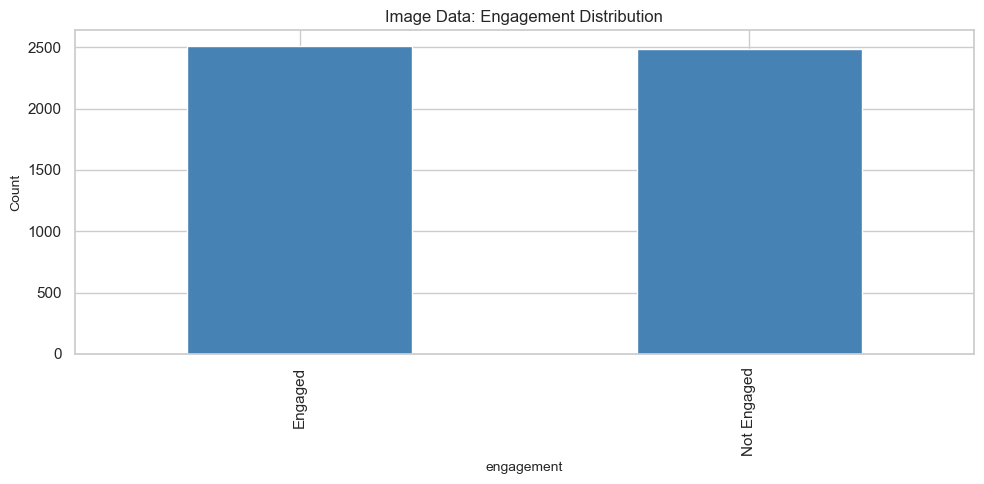

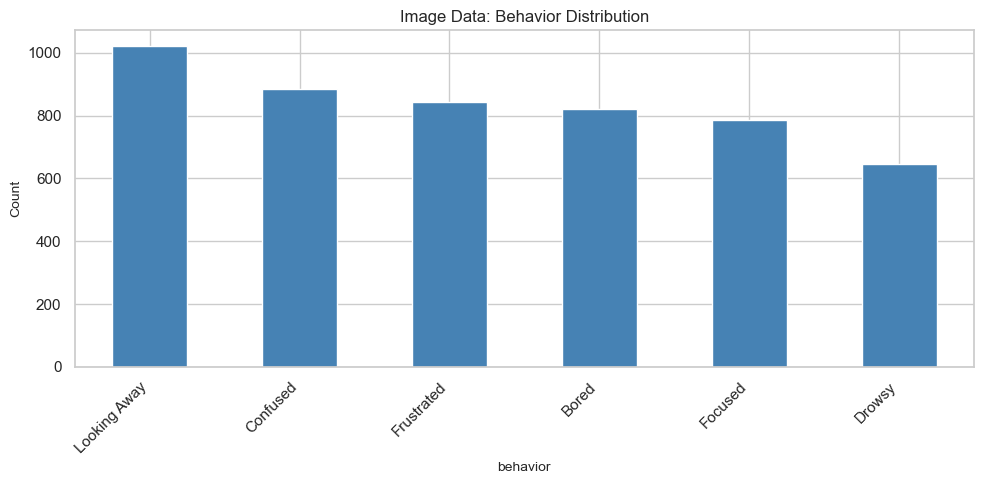

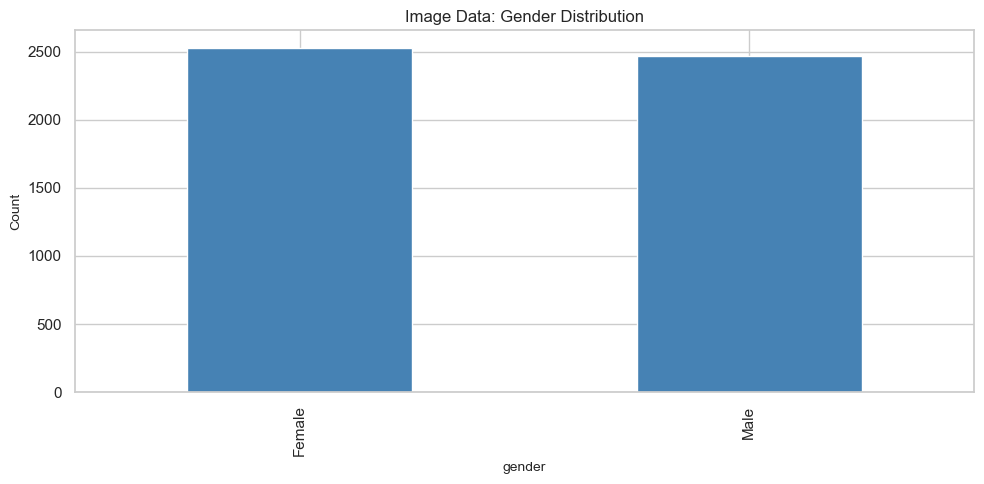

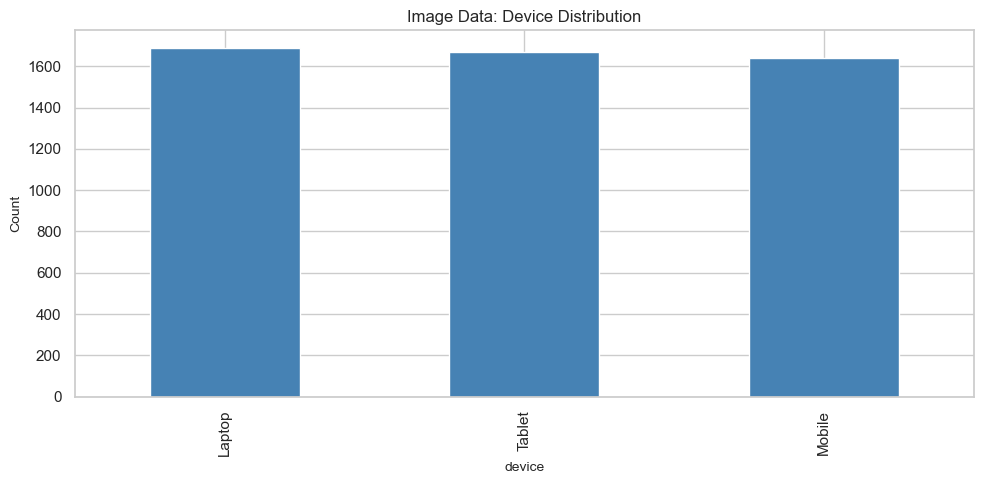

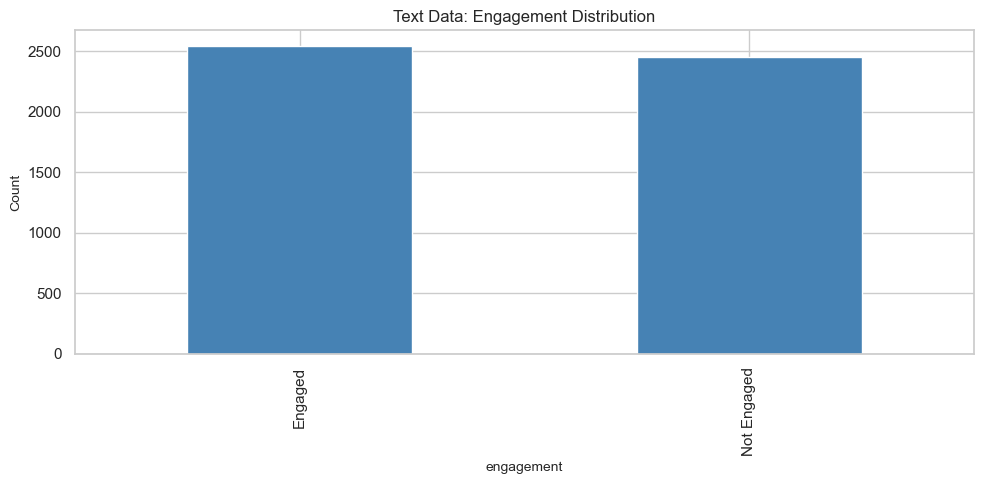

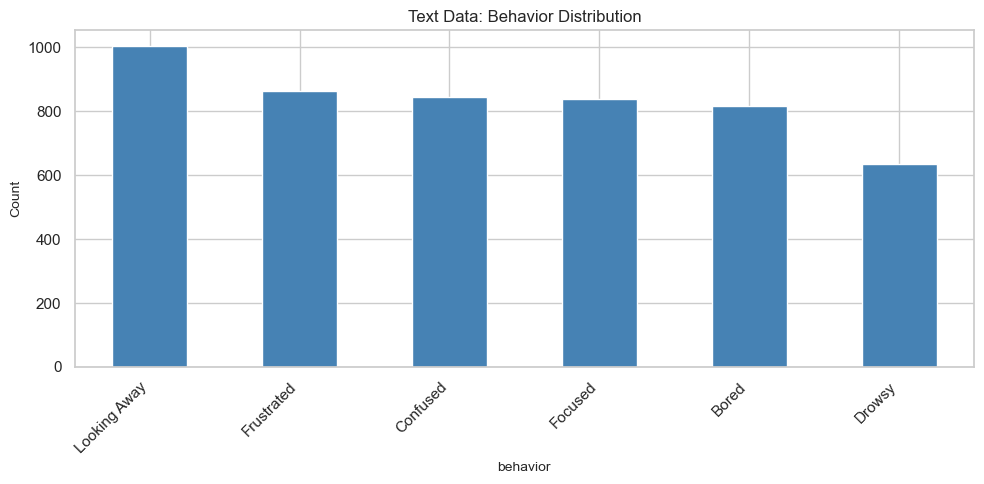

Behavior x Engagement (image data):


engagement,Engaged,Not Engaged,All
behavior,,,
Bored,0,821,821
Confused,885,0,885
Drowsy,0,646,646
Focused,786,0,786
Frustrated,842,0,842
Looking Away,0,1020,1020
All,2513,2487,5000


Behavior x Engagement (text data):


engagement,Engaged,Not Engaged,All
behavior,,,
Bored,0,815,815
Confused,846,0,846
Drowsy,0,635,635
Focused,838,0,838
Frustrated,863,0,863
Looking Away,0,1003,1003
All,2547,2453,5000


In [6]:
def plot_count(series, title, rotate=False):
    vc = series.value_counts()
    ax = vc.plot(kind='bar', color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Count')
    if rotate:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in ['engagement', 'behavior', 'gender', 'device']:
    if col in image_df.columns:
        plot_count(image_df[col], f'Image Data: {col.title()} Distribution', rotate=(col == 'behavior'))

for col in ['engagement', 'behavior']:
    if col in text_df.columns:
        plot_count(text_df[col], f'Text Data: {col.title()} Distribution', rotate=(col == 'behavior'))

print('Behavior x Engagement (image data):')
display(pd.crosstab(image_df['behavior'], image_df['engagement'], margins=True))

print('Behavior x Engagement (text data):')
display(pd.crosstab(text_df['behavior'], text_df['engagement'], margins=True))

## 3) Numeric Variable Analysis

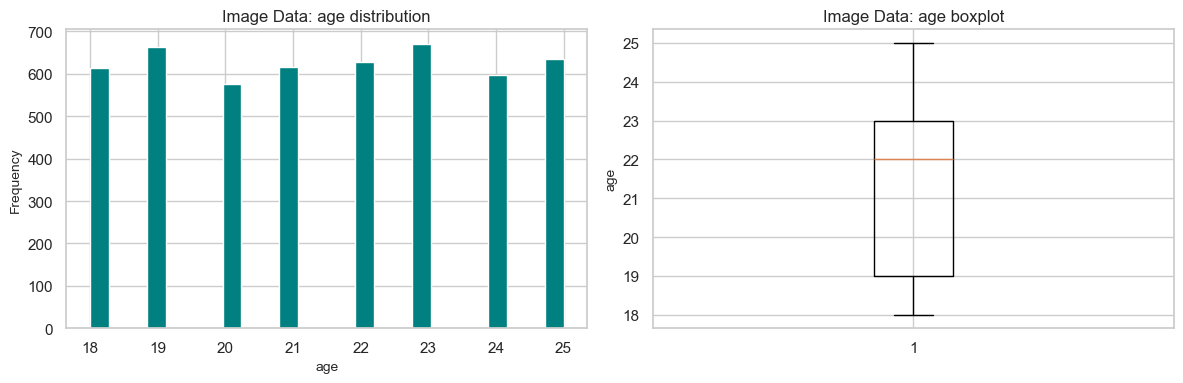

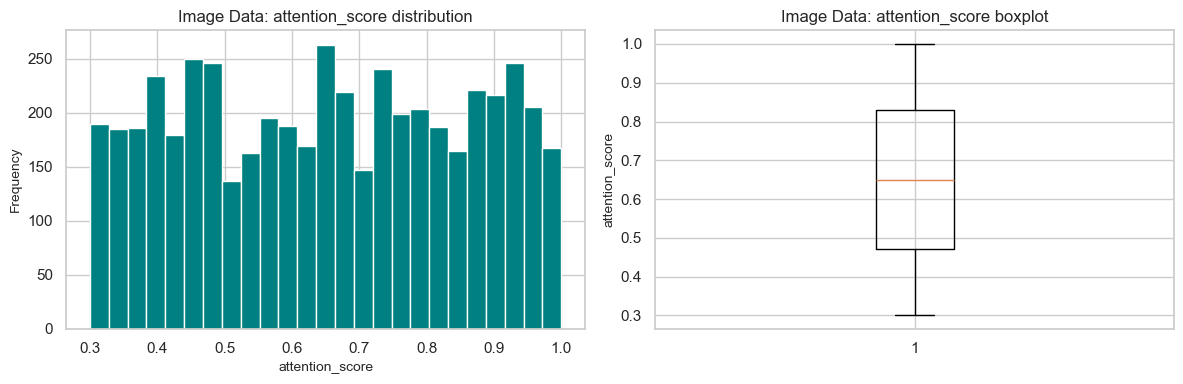

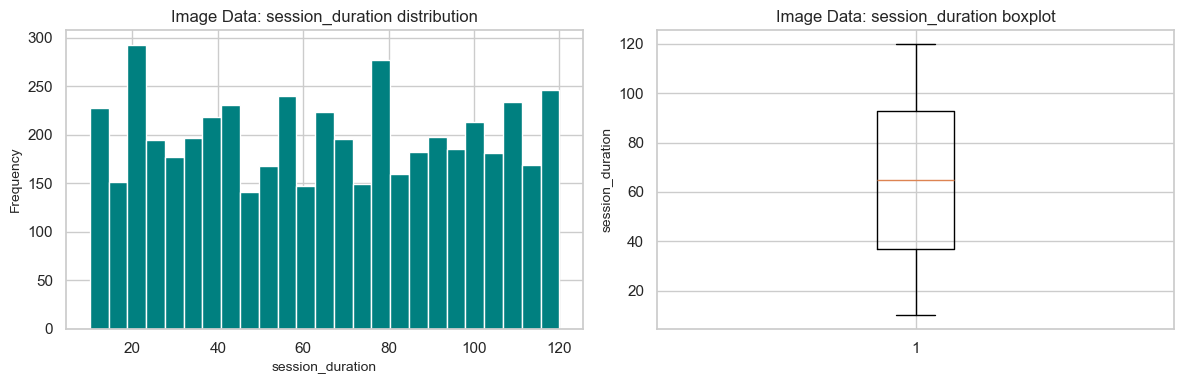

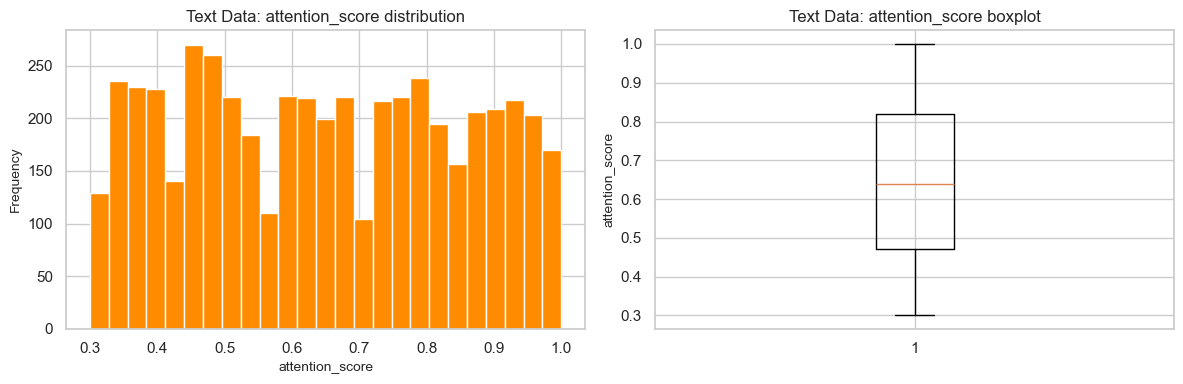

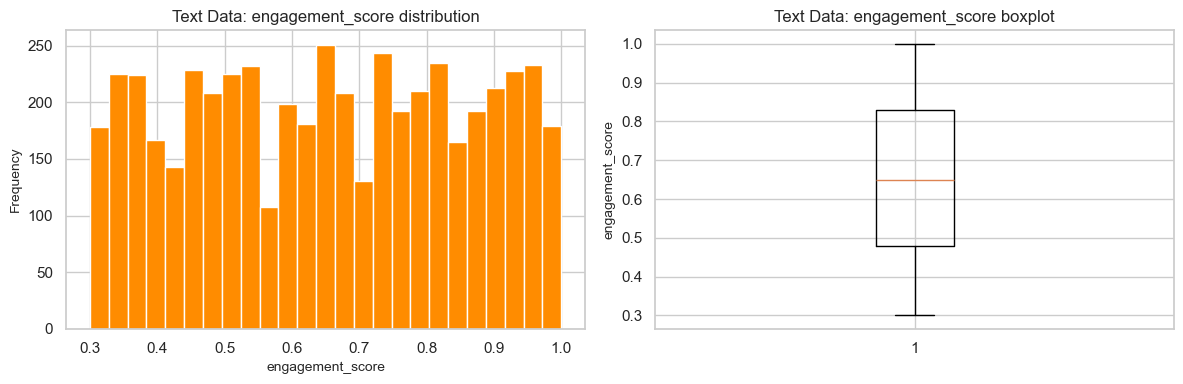

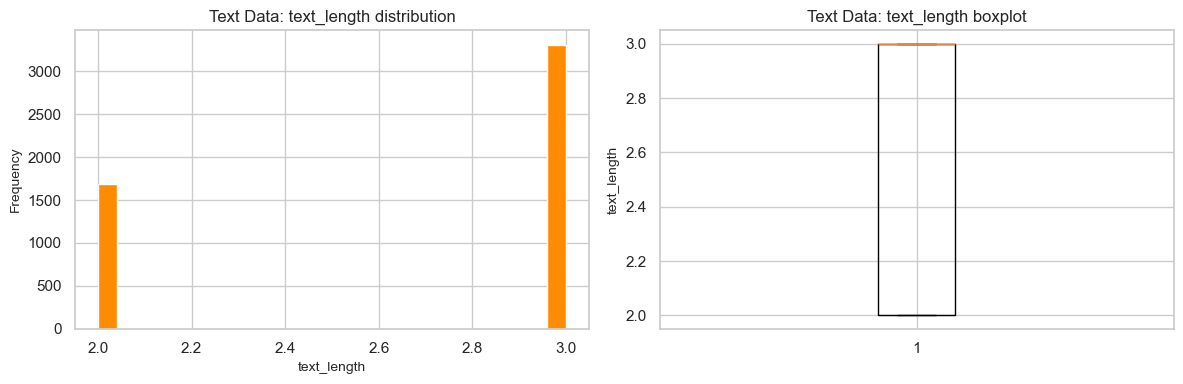

Mean numeric values by engagement (image data):


,age,attention_score,session_duration
engagement,,,
Engaged,21.487,0.640,65.960
Not Engaged,21.535,0.662,63.563


Mean numeric values by engagement (text data):


,attention_score,engagement_score,text_length
engagement,,,
Engaged,0.642,0.662,2.846
Not Engaged,0.651,0.644,2.471


In [7]:
image_num_cols = [c for c in ['age', 'attention_score', 'session_duration'] if c in image_df.columns]
text_num_cols = [c for c in ['attention_score', 'engagement_score', 'text_length'] if c in text_df.columns]

for col in image_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    image_df[col].plot(kind='hist', bins=25, ax=axes[0], color='teal', edgecolor='white')
    axes[0].set_title(f'Image Data: {col} distribution')
    axes[0].set_xlabel(col)

    axes[1].boxplot(image_df[col].dropna(), vert=True)
    axes[1].set_title(f'Image Data: {col} boxplot')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

for col in text_num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    text_df[col].plot(kind='hist', bins=25, ax=axes[0], color='darkorange', edgecolor='white')
    axes[0].set_title(f'Text Data: {col} distribution')
    axes[0].set_xlabel(col)

    axes[1].boxplot(text_df[col].dropna(), vert=True)
    axes[1].set_title(f'Text Data: {col} boxplot')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

if 'engagement' in image_df.columns:
    grouped = image_df.groupby('engagement')[image_num_cols].mean().round(3)
    print('Mean numeric values by engagement (image data):')
    display(grouped)

if 'engagement' in text_df.columns:
    grouped = text_df.groupby('engagement')[text_num_cols].mean().round(3)
    print('Mean numeric values by engagement (text data):')
    display(grouped)

## 4) Correlation and Relationships

Correlation Matrix - Image Data


,age,attention_score,session_duration
age,1.000000,-0.013386,-0.030363
attention_score,-0.013386,1.000000,-0.064655
session_duration,-0.030363,-0.064655,1.000000


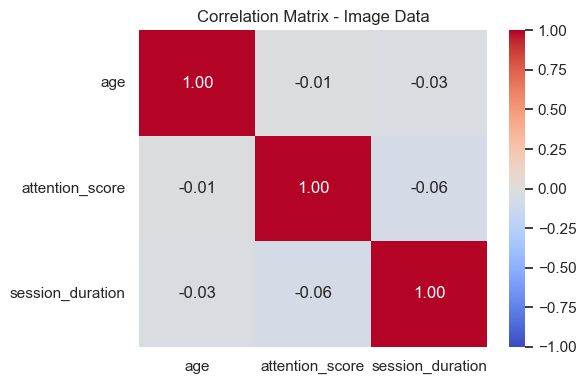

Correlation Matrix - Text Data


,attention_score,engagement_score,text_length
attention_score,1.000000,-0.064339,-0.026806
engagement_score,-0.064339,1.000000,-0.005771
text_length,-0.026806,-0.005771,1.000000


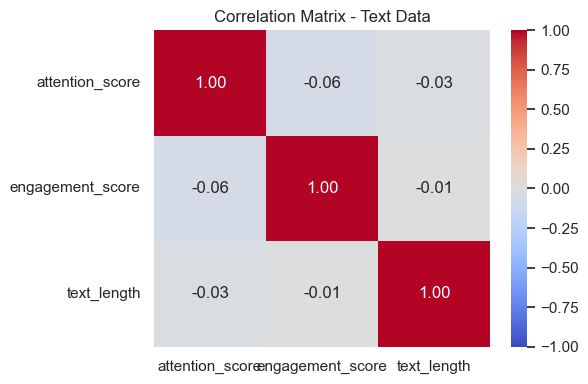

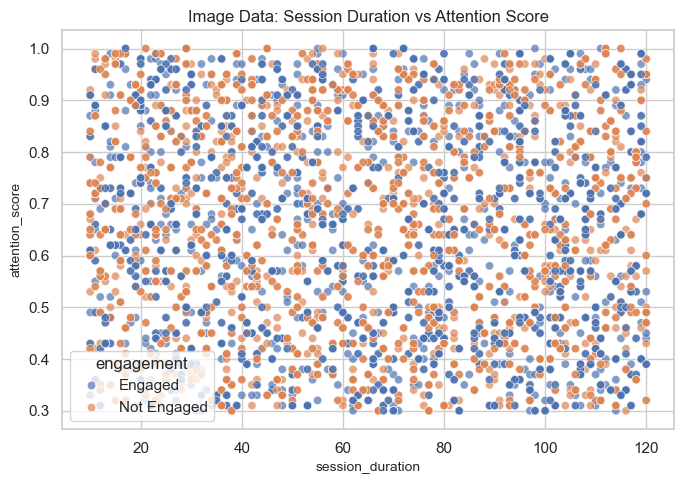

In [8]:
def show_corr(df, cols, title):
    if len(cols) < 2:
        print(f'Not enough numeric columns for correlation in {title}.')
        return
    corr = df[cols].corr(numeric_only=True)
    print(title)
    display(corr)

    plt.figure(figsize=(6, 4))
    if HAS_SEABORN:
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    else:
        plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
        plt.yticks(range(len(corr.index)), corr.index)
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')
        plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_corr(image_df, image_num_cols, 'Correlation Matrix - Image Data')
show_corr(text_df, text_num_cols, 'Correlation Matrix - Text Data')

if {'attention_score', 'session_duration'}.issubset(image_df.columns):
    plt.figure(figsize=(7, 5))
    if HAS_SEABORN:
        sns.scatterplot(data=image_df, x='session_duration', y='attention_score', hue='engagement', alpha=0.7)
    else:
        for group, data in image_df.groupby('engagement'):
            plt.scatter(data['session_duration'], data['attention_score'], label=group, alpha=0.7)
        plt.legend()
    plt.title('Image Data: Session Duration vs Attention Score')
    plt.tight_layout()
    plt.show()

## 5) Text-Specific EDA (Keywords and Text Fields)

Top keywords:


,count
keywords,
learning,2636
fatigue,2476
focus,2472
attention,2416


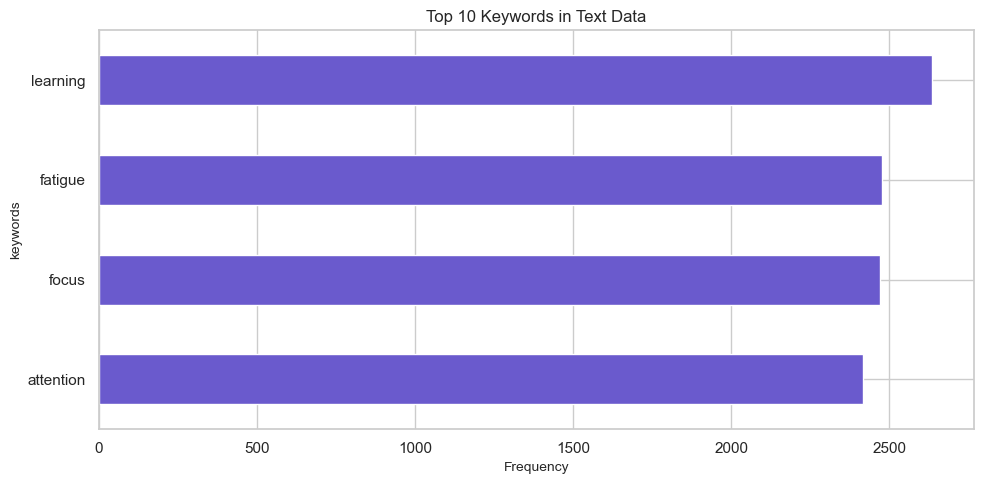

Short text word-count summary:


,short_text_word_count
count,5000.000000
mean,2.662000
std,0.473076
min,2.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,3.000000


Detailed text word-count summary:


,detailed_text_word_count
count,5000.000000
mean,5.662000
std,0.473076
min,5.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,6.000000


In [9]:
keyword_series = (
    text_df['keywords']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)

keyword_counts = keyword_series.value_counts()
print('Top keywords:')
display(keyword_counts.head(15).to_frame('count'))

keyword_counts.head(10).sort_values().plot(kind='barh', color='slateblue')
plt.title('Top 10 Keywords in Text Data')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

if 'short_text' in text_df.columns:
    short_text_len = text_df['short_text'].astype(str).str.split().str.len()
    print('Short text word-count summary:')
    display(short_text_len.describe().to_frame('short_text_word_count'))

if 'detailed_text' in text_df.columns:
    detailed_text_len = text_df['detailed_text'].astype(str).str.split().str.len()
    print('Detailed text word-count summary:')
    display(detailed_text_len.describe().to_frame('detailed_text_word_count'))

## 6) Merge Image + Text Data for Cross-Modal Insights

Original image rows: 5000 | unique sample_id: 2120
Original text rows: 5000 | unique sample_id: 2120
Raw inner-merge rows (with duplicates): 11536
Deduplicated merged shape: (2120, 18)


,sample_id,image_name_img,engagement_img,behavior_img,age,gender,device,attention_score_img,session_duration,image_name_txt,engagement_txt,behavior_txt,short_text,detailed_text,attention_score_txt,engagement_score,keywords,text_length
0,38615ca3-f04f-4a01-8793-a4bb362fbd69,0020.jpg,Engaged,Confused,23,Male,Laptop,0.30,100,0020.jpg,Engaged,Confused,Learner shows confusion,Learner shows confusion during learning session,0.42,0.94,"focus, attention",3
1,667b0dd6-edcf-4b9e-8c9f-fbeff5165fc3,0021.jpg,Engaged,Confused,22,Female,Laptop,0.72,51,0021.jpg,Engaged,Confused,Learner shows confusion,Learner shows confusion during learning session,0.52,0.52,"learning, fatigue",3
2,58434a4d-a70c-4757-a01f-3a866654ccc8,0032.jpg,Engaged,Confused,24,Female,Mobile,0.67,53,0032.jpg,Engaged,Confused,Student appears confused,Student appears confused during learning session,0.76,0.36,"attention, fatigue",3


Engagement label agreement across modalities: 100.00%
Behavior label agreement across modalities: 100.00%
Attention score difference summary (image - text):


,attention_diff
count,2.120000e+03
mean,1.256856e-18
std,2.874956e-01
min,-6.700000e-01
25%,-2.100000e-01
50%,0.000000e+00
75%,2.100000e-01
max,6.700000e-01


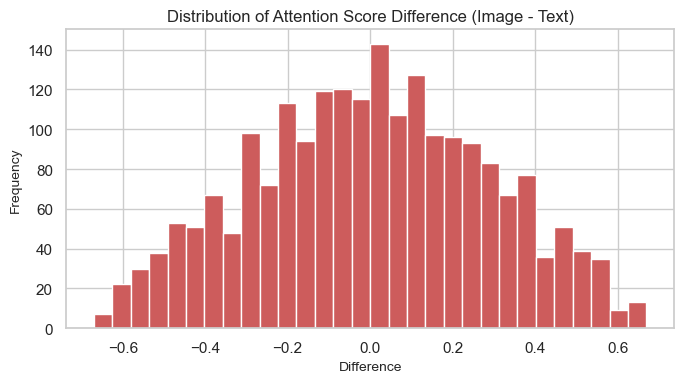

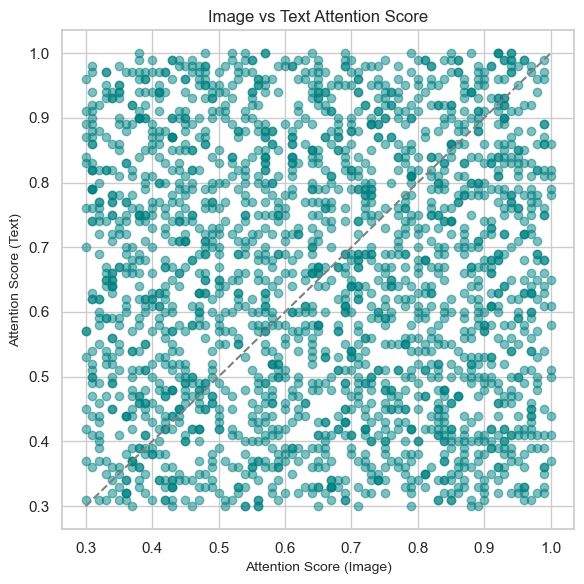

In [10]:
# Use deduplicated sample_id records for robust cross-modal comparisons.
image_unique = image_df.drop_duplicates(subset='sample_id').copy()
text_unique = text_df.drop_duplicates(subset='sample_id').copy()

print('Original image rows:', len(image_df), '| unique sample_id:', image_unique['sample_id'].nunique())
print('Original text rows:', len(text_df), '| unique sample_id:', text_unique['sample_id'].nunique())

# Optional: keep raw merge size for transparency.
raw_merge_rows = image_df.merge(text_df, on='sample_id', how='inner').shape[0]
print('Raw inner-merge rows (with duplicates):', raw_merge_rows)

merged_df = image_unique.merge(text_unique, on='sample_id', suffixes=('_img', '_txt'), how='inner')
print('Deduplicated merged shape:', merged_df.shape)

display(merged_df.head(3))

if {'engagement_img', 'engagement_txt'}.issubset(merged_df.columns):
    agreement = (merged_df['engagement_img'] == merged_df['engagement_txt']).mean() * 100
    print(f'Engagement label agreement across modalities: {agreement:.2f}%')

if {'behavior_img', 'behavior_txt'}.issubset(merged_df.columns):
    behavior_agreement = (merged_df['behavior_img'] == merged_df['behavior_txt']).mean() * 100
    print(f'Behavior label agreement across modalities: {behavior_agreement:.2f}%')

if {'attention_score_img', 'attention_score_txt'}.issubset(merged_df.columns):
    merged_df['attention_diff'] = merged_df['attention_score_img'] - merged_df['attention_score_txt']

    print('Attention score difference summary (image - text):')
    display(merged_df['attention_diff'].describe().to_frame('attention_diff'))

    plt.figure(figsize=(7, 4))
    merged_df['attention_diff'].plot(kind='hist', bins=30, color='indianred', edgecolor='white')
    plt.title('Distribution of Attention Score Difference (Image - Text)')
    plt.xlabel('Difference')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(
        merged_df['attention_score_img'],
        merged_df['attention_score_txt'],
        alpha=0.5,
        color='teal'
    )
    min_val = min(merged_df['attention_score_img'].min(), merged_df['attention_score_txt'].min())
    max_val = max(merged_df['attention_score_img'].max(), merged_df['attention_score_txt'].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')
    plt.title('Image vs Text Attention Score')
    plt.xlabel('Attention Score (Image)')
    plt.ylabel('Attention Score (Text)')
    plt.tight_layout()
    plt.show()

In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2120 entries, 0 to 2119
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sample_id            2120 non-null   object 
 1   image_name_img       2120 non-null   object 
 2   engagement_img       2120 non-null   object 
 3   behavior_img         2120 non-null   object 
 4   age                  2120 non-null   int64  
 5   gender               2120 non-null   object 
 6   device               2120 non-null   object 
 7   attention_score_img  2120 non-null   float64
 8   session_duration     2120 non-null   int64  
 9   image_name_txt       2120 non-null   object 
 10  engagement_txt       2120 non-null   object 
 11  behavior_txt         2120 non-null   object 
 12  short_text           2120 non-null   object 
 13  detailed_text        2120 non-null   object 
 14  attention_score_txt  2120 non-null   float64
 15  engagement_score     2120 non-null   f